# Prueba Técnica Científico de datos - Fraccionamiento Transaccional


In [1]:
# Ajusta el directorio de trabajo a la raiz del proyecto.
import os

from pathlib import Path

project_root = Path.cwd().parent

os.chdir(project_root)

## 1. Librerías y configuración

In [2]:
import datetime as dt
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from python.utils import cleaning
from python.utils import detection
from python.utils import eda
from python.utils import io


In [3]:
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', None)

sns.set_theme(style='whitegrid', context='talk')

### 1.1. Carga de datos

In [4]:
file = 'sample_user_id_50'
path = os.path.join('data', f'{file}.parquet')
data = io.load_data(path)

In [5]:
# Con la lectura se agregan dos columna fecha y hora por separado.
data.shape

(5372416, 10)

## 2. Cobertura, volumen y calidad

Aqui revisamos tamaños, rango temporal, cardinalidades, nulos, ids duplicados y distribucion general por tipo de transacción.


In [6]:
# Construye un resumen general del dataset.
overview_df = eda.build_data_overview(data)

overview_df

,n_transactions,min_transaction_date,max_transaction_date,n_users,n_accounts,n_merchants,n_subsidiaries,duplicated_ids,non_positive_amounts
0,5372416,2021-01-01 00:01:17,2021-11-30 23:59:49,974422,977013,3,15079,3,0


### 2.1. Duplicidades de __ids_

In [7]:
duplicated_id = data['_id'].duplicated()
duplicated_ids = data.loc[duplicated_id, '_id'].unique()

duplicated_ids

array(['c52a54da9927f445e5f621d6dac29bf4',
       '52227fbe95311404092cbc8fbf2d320b',
       'd737f8d70694471f3061002db7fb2ac1'], dtype=object)

In [8]:
# Se encuentran duplicidades de _id y algunas solo difieren por 1 segundo.
val = data['_id'].isin(duplicated_ids)
data[val]

,merchant_id,_id,subsidiary,transaction_date,account_number,user_id,transaction_amount,transaction_type,transaction_day,transaction_time
500669,075d178871d8d48502bf1f54887e52fe,c52a54da9927f445e5f621d6dac29bf4,ef6ca49817c5526c145d3cf89b79ba5b,2021-08-03 16:10:11,4e355451697d9365322913f3e4117503,4e6b357a05727beeb7d7faf836554683,23.777820,CREDITO,2021-08-03,16:10:11
500670,075d178871d8d48502bf1f54887e52fe,c52a54da9927f445e5f621d6dac29bf4,ef6ca49817c5526c145d3cf89b79ba5b,2021-08-03 16:10:10,4e355451697d9365322913f3e4117503,4e6b357a05727beeb7d7faf836554683,23.777820,CREDITO,2021-08-03,16:10:10
576332,075d178871d8d48502bf1f54887e52fe,52227fbe95311404092cbc8fbf2d320b,024b459a0851f51d731099ac10d1b30a,2021-08-26 14:58:58,8495c31cd0ba9c1c6ccf493cdf0e3558,6405b4845df13af0ca2f03714ff486c2,475.556401,CREDITO,2021-08-26,14:58:58
576333,075d178871d8d48502bf1f54887e52fe,52227fbe95311404092cbc8fbf2d320b,024b459a0851f51d731099ac10d1b30a,2021-08-26 14:58:58,8495c31cd0ba9c1c6ccf493cdf0e3558,6405b4845df13af0ca2f03714ff486c2,475.556401,CREDITO,2021-08-26,14:58:58
5251903,838a8fa992a4aa2fb5a0cf8b15b63755,d737f8d70694471f3061002db7fb2ac1,fb06b4a71938b984fc729784c1db0fca,2021-09-05 15:44:13,79f3ffcf1cdf1d6e7166e9ef87d64247,cb5364b29887ac940a8fc0eb02f7e6e4,99.866844,CREDITO,2021-09-05,15:44:13
5251904,838a8fa992a4aa2fb5a0cf8b15b63755,d737f8d70694471f3061002db7fb2ac1,fb06b4a71938b984fc729784c1db0fca,2021-09-05 15:44:13,79f3ffcf1cdf1d6e7166e9ef87d64247,cb5364b29887ac940a8fc0eb02f7e6e4,99.866844,CREDITO,2021-09-05,15:44:13


### 2.2. Campos con registros nulos

In [9]:
nulls_df = data.isna().sum().rename('null_count').reset_index()

nulls_df = nulls_df.rename(columns={'index': 'column'})

nulls_df = nulls_df.sort_values('null_count', ascending=False).reset_index(drop=True)

nulls_df

,column,null_count
0,merchant_id,0
1,_id,0
2,subsidiary,0
3,transaction_date,0
4,account_number,0
5,user_id,0
6,transaction_amount,0
7,transaction_type,0
8,transaction_day,0
9,transaction_time,0


## 3. Reglas Operativas de limpieza

In [10]:
# Cantidad de registros antes de la limpieza.
n_rows_before = len(data)

### 3.1. Duplicados de `_id`

- Si un `_id` aparece mas de una vez y todas las variables de negocio son iguales, se conserva una sola fila.
- Si un `_id` aparece mas de una vez y solo cambia `transaction_date` por unos pocos segundos (5s por defecto), pero el resto de variables de negocio coincide, tambien se trata como duplicado tecnico y se conserva una sola fila.
- Si un `_id` repetido cambia variables de negocio relevantes como `user_id`, `account_number`, `merchant_id`, `subsidiary`, `transaction_amount` o `transaction_type`, no se elimina automaticamente.

In [11]:
# Elimina duplicados seguros de `_id`.
data = cleaning.deduplicate_transaction_ids(data)

### 3.2. Campos nulos en variables obligatorias

Hay un conjunto de campos que no deberían ser nulos porque son indispensables para analizar el patrón de fraccionamiento transaccional.

La regla de limpieza propuesta es eliminar las filas donde falte al menos uno de estos campos:

- `_id`
- `transaction_date`
- `account_number`
- `user_id`
- `transaction_amount`
- `transaction_type`

#### Justificación de negocio

- `_id` es necesario para trazabilidad y control del registro.
- `transaction_date` es indispensable porque el problema depende de una ventana temporal de 24 horas.
- `account_number` y `user_id` son claves para construir la unidad de análisis del patrón.
- `transaction_amount` es la señal principal para evaluar fraccionamiento.
- `transaction_type` permite distinguir la naturaleza del movimiento y evita mezclar comportamientos distintos.

En esta etapa, `merchant_id` y `subsidiary` no se tratan como obligatorios absolutos, porque aunque aportan contexto importante sobre el destino observable, el problema no garantiza que toda transacción deba tener esa información disponible.

In [12]:
# Elimina filas con nulos en campos obligatorios.
data = cleaning.drop_null_required_fields(data)

### 3.3. Montos no válidos

En este problema, `transaction_amount` debe ser mayor que cero.

Las transacciones con monto cero o negativo se eliminan, porque no representan un movimiento válido para analizar fraccionamiento.


In [13]:
# Elimina filas con montos no positivos.
data = cleaning.drop_non_positive_transaction_amounts(data)

In [14]:
# Regsitros despues de la limpieza
n_rows_after = len(data)
n_removed_rows = n_rows_before - n_rows_after

pct_removed_rows = 100 * n_removed_rows / n_rows_before

In [15]:
print(f'Se removió el {pct_removed_rows:.4f}% de los registros.')

Se removió el 0.0001% de los registros.


## 4. Distribución

### 4.1. `transaction_type`

Calcula cantidad de transacciones, suma de montos, promedio, mediana, desviación estándar y el porcentaje que representa cada tipo sobre el total.

Sirve para comparar `CREDITO` y `DEBITO` antes de analizarlos en detalle.

In [16]:
# Construye una distribucion agregada para la columna `transaction_type`.
type_dist_df = eda.build_categorical_distribution(data, 'transaction_type')
type_dist_df

,transaction_type,n_transactions,total_amount,avg_amount,median_amount,std_amount,pct_transactions
0,DEBITO,4289838,8.796922e+08,205.064208,118.88910,253.743030,79.849371
1,CREDITO,1082575,1.493798e+08,137.985638,59.44455,173.173585,20.150629


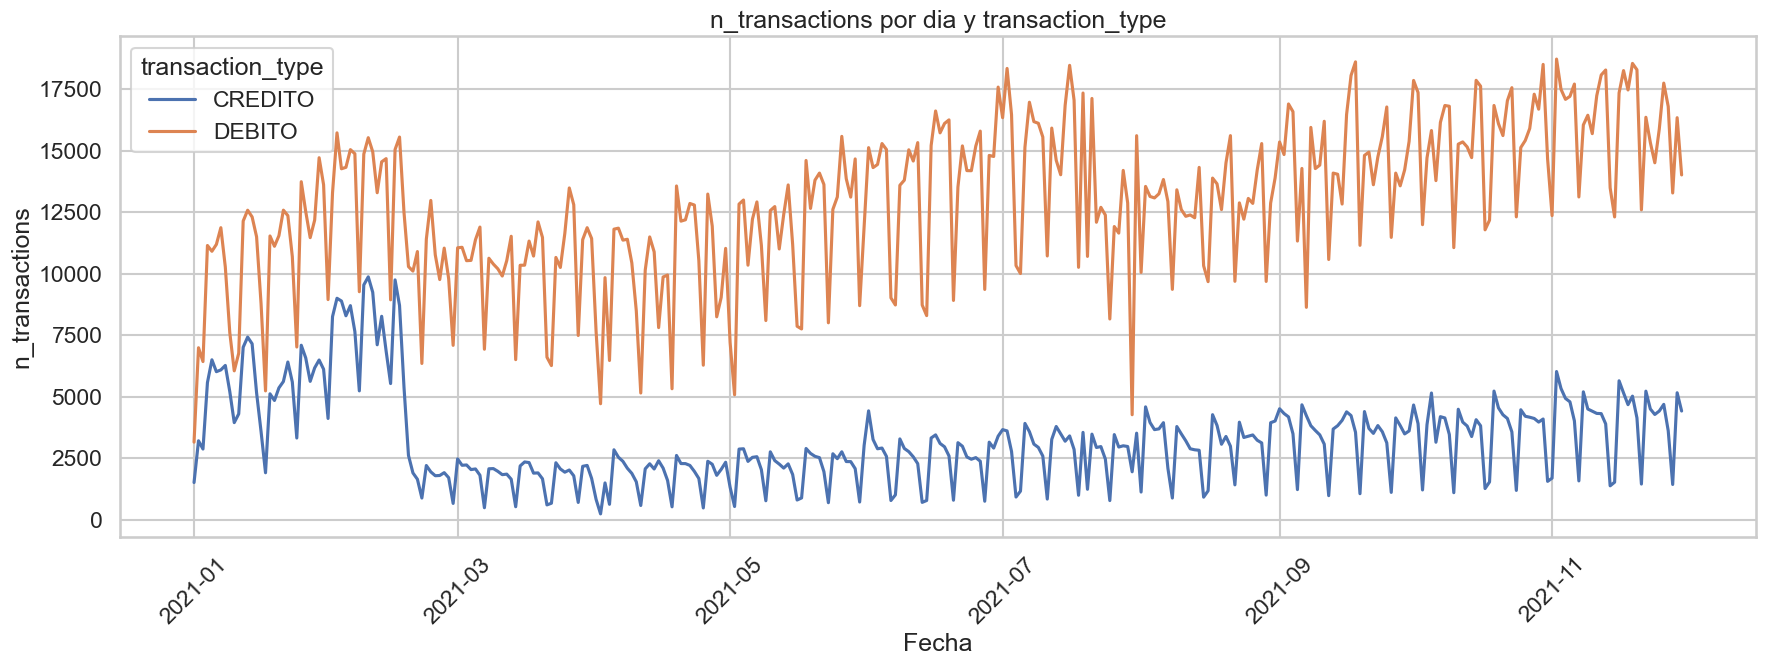

In [17]:
# Comportamiento en el tiempo de `transaction_type`.
daily_df = eda.build_daily_distribution(data, 'transaction_type')

eda.plot_daily_distribution(daily_df, 'transaction_type', 'n_transactions')

### 4.2. `merchant_id`

In [18]:
# Construye una distribucion agregada para la columna `merchant_id`.
merchant_dist_df = eda.build_categorical_distribution(data, 'merchant_id')

merchant_dist_df

,merchant_id,n_transactions,total_amount,avg_amount,median_amount,std_amount,pct_transactions
0,817d18cd3c31e40e9bff0566baae7758,3629066,8.067172e+08,222.293339,118.889100,265.894769,67.550019
1,838a8fa992a4aa2fb5a0cf8b15b63755,939213,8.476663e+07,90.252830,30.911166,138.758470,17.482144
2,075d178871d8d48502bf1f54887e52fe,804134,1.375882e+08,171.101089,107.000190,174.536129,14.967837


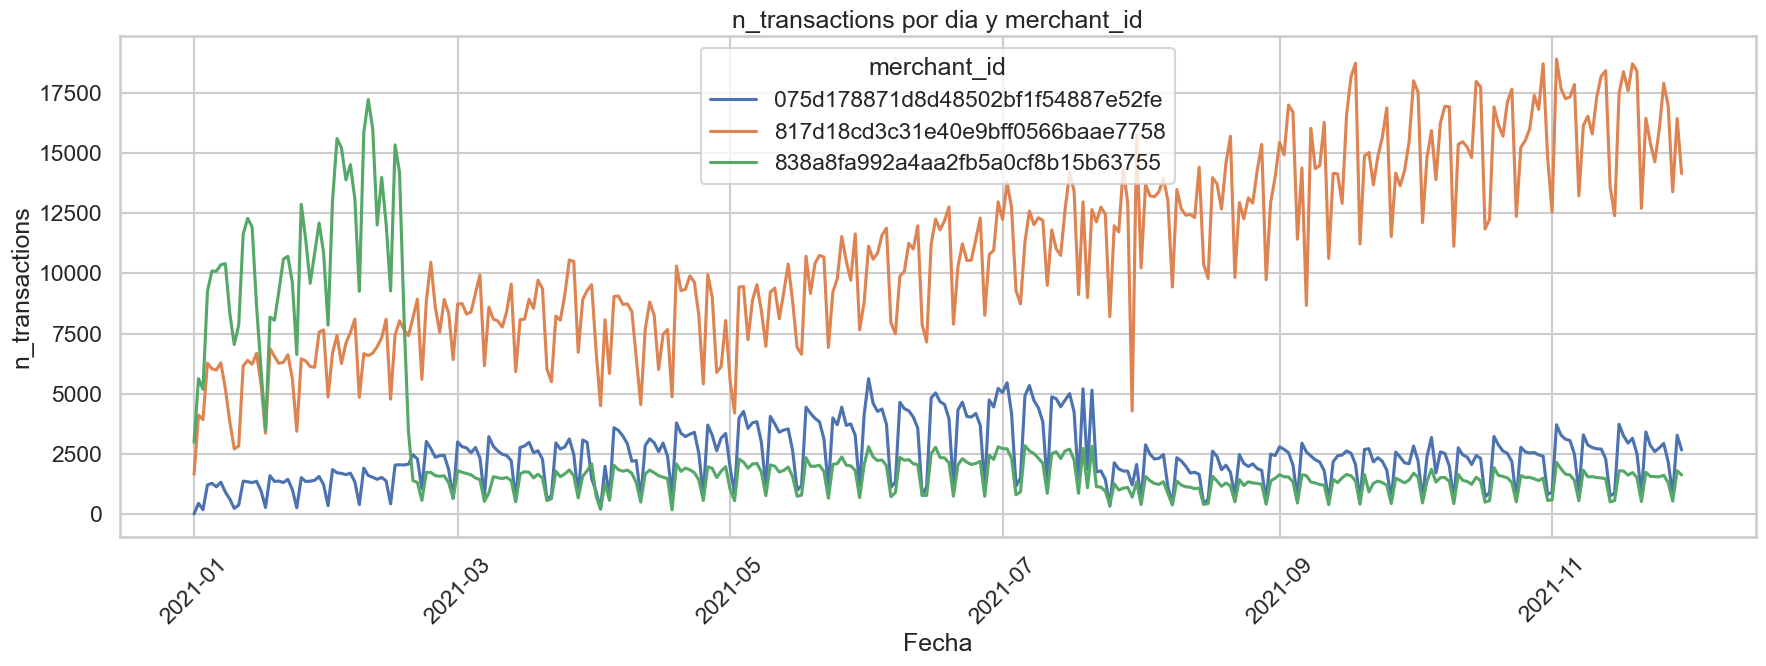

In [19]:
# Comportamiento en el tiempo de `merchant_id`.
daily_df = eda.build_daily_distribution(data, 'merchant_id')

eda.plot_daily_distribution(daily_df, 'merchant_id', 'n_transactions')

### 4.3. Comportamiento transaccional general

Este bloque explora el comportamiento general de la data en tiempo, montos, actividad por usuario y concentración por comercio y sucursal.

Sirve para entender el patrón normal antes de buscar señales de fraccionamiento.

In [20]:
# Construye percentiles de monto por `transaction_type`.
amount_percentiles_df = eda.build_amount_percentiles(data, 'transaction_type')
amount_percentiles_df

,transaction_type,p01,p05,p50,p95,p99
0,CREDITO,5.944455,5.944455,59.44455,594.445501,594.445501
1,DEBITO,5.944455,11.888910,118.88910,713.334601,1188.891002


In [21]:
# Construye actividad por usuario y su resumen percentil.
user_activity, user_activity_summary = eda.build_user_activity(data)
user_activity_summary

,n_users,p50_transactions,p90_transactions,p99_transactions,p50_total_amount,p90_total_amount,p99_total_amount
0,974422,2.0,13.0,48.0,332.889481,2568.004565,11068.575233


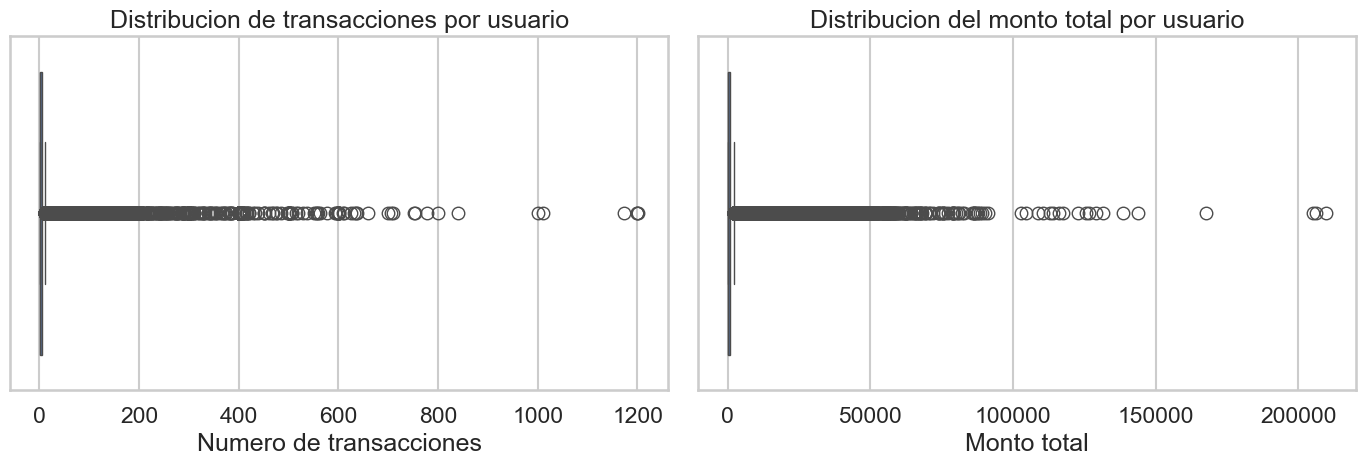

In [22]:
eda.plot_boxplot(
    data=user_activity,
    value_cols=['n_transactions', 'total_amount'],
    titles=[
        'Distribucion de transacciones por usuario',
        'Distribucion del monto total por usuario',
    ],
    xlabels=[
        'Numero de transacciones',
        'Monto total',
    ],
)

Ambos boxplots muestran una distribución fuertemente sesgada a la derecha.

La mayoría de los usuarios tiene pocas transacciones y montos totales relativamente bajos, mientras que un grupo pequeño concentra valores muy altos.

Esto indica una cola larga y presencia clara de outliers, por lo que no conviene describir este comportamiento solo con promedios. Para este problema, esa heterogeneidad justifica comparar cada entidad analítica contra una referencia del periodo observado.


In [23]:
group_cols = ['merchant_id', 'subsidiary']
merchant_subsidiary_df = eda.build_group_distribution(data, group_cols)

merchant_subsidiary_df.head()

,merchant_id,subsidiary,n_transactions,total_amount,avg_amount,pct_transactions,pct_total_amount
0,838a8fa992a4aa2fb5a0cf8b15b63755,f54e0b6b32831a6307361ed959903e76,179925,4.424867e+06,24.592843,3.349054,0.429986
1,838a8fa992a4aa2fb5a0cf8b15b63755,8c52a2d7745e37bcee79717300f796e3,85756,5.533314e+06,64.523934,1.596229,0.537699
2,838a8fa992a4aa2fb5a0cf8b15b63755,d4b621a24cc03e3f92155a7e241fa1c3,82412,4.547233e+06,55.176830,1.533985,0.441877
3,838a8fa992a4aa2fb5a0cf8b15b63755,dff70ce33784a932ce4a7efc81a43863,62348,2.988615e+06,47.934424,1.160521,0.290418
4,838a8fa992a4aa2fb5a0cf8b15b63755,d4b31b123120a4eefd51ba95975f2ae4,25401,1.917698e+06,75.496942,0.472804,0.186352


## 5. Definición del modelo analítico

Dado que el problema consiste en detectar un patrón comportamental de fraccionamiento transaccional y no se cuenta con etiquetas confirmadas de fraude, la solución propuesta no se basa en aprendizaje supervisado. En su lugar, se plantea un modelo analítico no supervisado, explicable y orientado a negocio, construido a partir de reglas heurísticas y un esquema de priorización por riesgo.

El modelo evalúa cada entidad analítica definida como `user_id + account_number + transaction_type` sobre ventanas móviles de 24 horas. Para cada ventana calcula señales asociadas al fenómeno de interés, principalmente frecuencia transaccional, monto acumulado, similitud entre montos, anomalía frente a una referencia diaria del periodo observado y dispersión operativa entre sedes y comercios observables.

A partir de estas señales, el modelo activa escenarios de riesgo que representan distintas manifestaciones posibles del fraccionamiento transaccional. La combinación de esos escenarios permite clasificar cada caso en salidas operativas como `pre_alerta`, `media` y `alta`.


### 5.1. Criterio de selección del modelo

Se selecciona un modelo heurístico no supervisado porque:
- no hay evidencia de etiquetas confiables para entrenar un modelo supervisado
- el fenómeno está definido por reglas de negocio y comportamiento agregado en 24 horas
- la solución debe ser interpretable y fácil de auditar
- permite construir una primera versión operativa con bajo costo de implementación

En una prueba de ciencia de datos, esta aproximación sigue siendo un modelo analítico válido porque transforma variables de entrada en una decisión estructurada, repetible y evaluable.


### 5.2. Unidad de analisis y features de ventana movil de 24 horas

La unidad de analisis del detector se fija en `user_id + account_number + transaction_type`.

Se elige esta combinacion porque:
- evita mezclar comportamientos de cuentas distintas del mismo usuario
- mantiene trazabilidad directa sobre la cuenta observada
- deja alertas mas auditables y accionables para la revision operativa

Con esta unidad se construyen features de ventana movil de 24 horas:
- numero de transacciones en 24 horas
- monto acumulado en 24 horas
- monto promedio y desviacion en 24 horas
- coeficiente de variacion de montos en la ventana


In [24]:
# La unidad final se fija a nivel usuario-cuenta-tipo.
entity_cols = ['user_id', 'account_number', 'transaction_type']

In [25]:
# Se toma una entidad real para revisar el flujo con la unidad elegida.
sample_user_id = 'ffe087343f4c8aad20e37122eac9b85c'
sample_day = dt.date(2021, 1, 7)

sample_entity_df = data.loc[
    (data['user_id'] == sample_user_id)
    & (data['transaction_date'].dt.date == sample_day),
    entity_cols,
]

sample_entity_df = sample_entity_df.drop_duplicates().reset_index(drop=True)
sample_entity = sample_entity_df.iloc[0].to_dict()

sample_entity_df.head()

,user_id,account_number,transaction_type
0,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO


In [26]:
# Construye features de ventana movil de 24 horas.
window_features = detection.build_window_features(
    data=data,
    entity_cols=entity_cols,
    window='24h',
)

### 5.3. Distribucion de features de ventana

Esta seccion resume la distribucion de `count`, `sum` y `cv` para sustentar umbrales del score con el comportamiento observado en la base.


In [27]:
window_feature_dist_df = detection.build_window_feature_distribution(
    window_features=window_features,
    value_cols=['count', 'sum', 'cv'],
)

window_feature_dist_df

,feature,p01,p05,p50,p95,p99
0,count,1.000000,1.000000,1.000000,3.000000,46.000000
1,sum,9.511128,14.266692,118.889100,891.668252,1902.225604
2,cv,0.000000,0.000000,0.282843,1.157084,1.352726


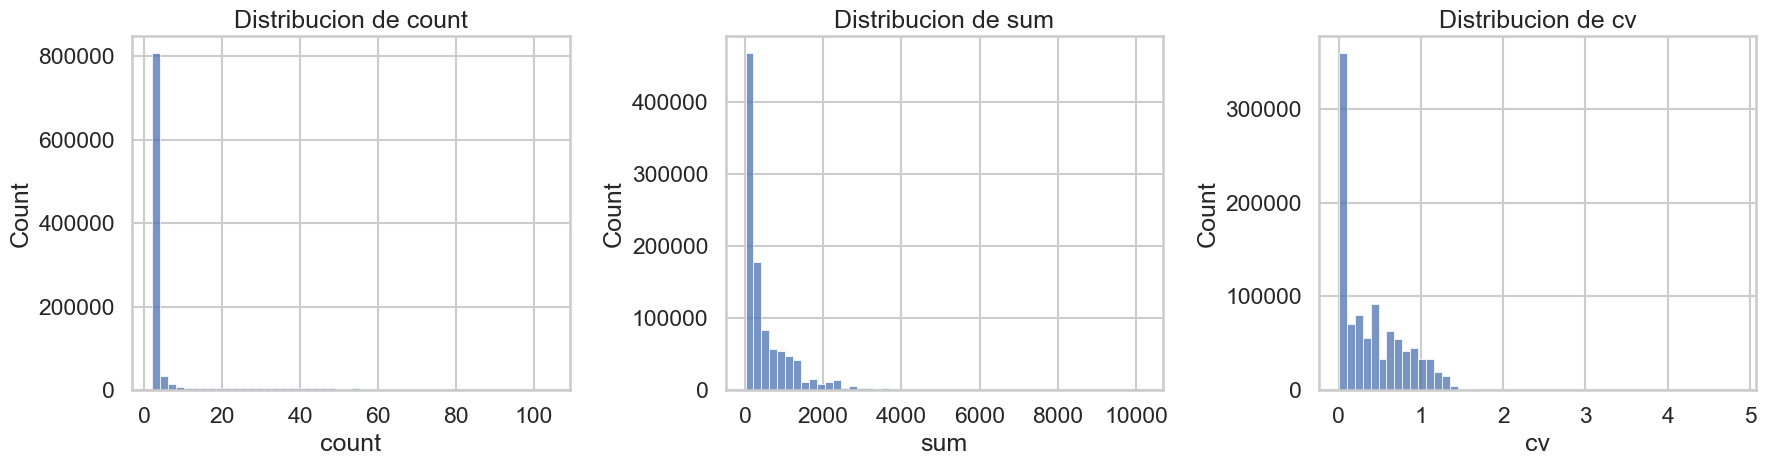

In [28]:
detection.plot_window_feature_distribution(
    window_features=window_features,
    value_cols=['count', 'sum', 'cv'],
    bins=50,
)

### 5.4. Hipótesis

H1. Una entidad analítica presenta múltiples transacciones en 24 horas cuya suma agregada es materialmente alta.

H2. Los montos de esa ventana son muy parecidos o poco variables.


In [29]:
# Inspecciona un caso puntual para revisar si una ventana concreta parece fraccionamiento.
cond = (
    window_features['transaction_day'].eq(sample_day)
    & window_features.loc[:, entity_cols].eq(pd.Series(sample_entity)).all(axis=1)
)

window_features.loc[cond].sort_values(['sum', 'cv'], ascending=[False, True])


,user_id,account_number,transaction_type,transaction_date,count,sum,mean,std,cv,transaction_day
5369999,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO,2021-01-07 19:45:22,19.0,112.970801,5.945832,0.001206,0.000203,2021-01-07
5369998,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO,2021-01-07 19:44:41,18.0,107.023968,5.945776,0.001216,0.000204,2021-01-07
5369997,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO,2021-01-07 19:38:49,17.0,101.079513,5.945854,0.001206,0.000203,2021-01-07
5369996,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO,2021-01-07 19:38:19,16.0,95.132680,5.945793,0.001218,0.000205,2021-01-07
5369995,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO,2021-01-07 19:34:35,15.0,89.188225,5.945882,0.001206,0.000203,2021-01-07
5369994,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO,2021-01-07 19:29:55,14.0,83.241392,5.945814,0.001221,0.000205,2021-01-07
5369993,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO,2021-01-07 16:13:22,13.0,77.296937,5.945918,0.001204,0.000202,2021-01-07
5369992,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO,2021-01-07 15:51:40,12.0,71.350105,5.945842,0.001224,0.000206,2021-01-07
5369991,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO,2021-01-07 15:45:42,11.0,65.405650,5.945968,0.001200,0.000202,2021-01-07
5369990,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO,2021-01-07 15:33:39,10.0,59.458817,5.945882,0.001228,0.000207,2021-01-07


In [30]:
# Consolida una sola ventana diaria por entidad para evaluar hipotesis a nivel dia.
alerts = detection.build_daily_window_alerts(
    window_features=window_features,
    entity_cols=entity_cols,
)

In [31]:
# Aplica H1 y H2 sobre cada ventana diaria.
# La regla toma valor 1 si la ventana supera su umbral y 0 en caso contrario.
# H1 usa `count` y `sum`; H2 usa `cv` bajo junto con frecuencia alta.
alerts = detection.apply_window_hypothesis_rules(alerts=alerts)

In [32]:
# `alerts` conserva la ultima ventana observada por entidad y por dia.
cond = (
    alerts['transaction_day'].eq(sample_day)
    & alerts.loc[:, entity_cols].eq(pd.Series(sample_entity)).all(axis=1)
)

alerts.loc[cond]


,user_id,account_number,transaction_type,transaction_date,count,sum,mean,std,cv,transaction_day,h1_tx_count,h1_amount,h2_low_cv
4636915,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO,2021-01-07 19:45:22,19.0,112.970801,5.945832,0.001206,0.000203,2021-01-07,1,0,1


H3. El día consolidado resulta anómalo frente a la referencia diaria del periodo observado para la entidad analítica.


In [33]:
# Construye una referencia diaria de la entidad analítica dentro del periodo observado.
# `entity_day` resume frecuencia, monto y z-scores diarios respecto a esa referencia.
entity_day = detection.build_daily_baseline_features(
    data=data,
    entity_cols=entity_cols,
)

In [34]:
# Une la referencia diaria a la tabla de alertas para medir anomalia
# frente al patron consolidado del periodo observado para la entidad.
alerts = detection.merge_daily_baseline_features(
    alerts=alerts,
    baseline_df=entity_day,
    entity_cols=entity_cols,
)

In [35]:
# Aplica H3 sobre cada dia consolidado.
# La regla toma valor 1 si el z-score del dia supera el umbral de anomalia
# respecto a la referencia del periodo observado; 0 en caso contrario.
# Se evalua por separado para frecuencia diaria y monto diario.
alerts = detection.apply_baseline_hypothesis_rules(alerts=alerts)

In [36]:
cond = (
    alerts['transaction_day'].eq(sample_day)
    & alerts.loc[:, entity_cols].eq(pd.Series(sample_entity)).all(axis=1)
)

alerts.loc[cond]


,user_id,account_number,transaction_type,transaction_date,count,sum,mean,std,cv,transaction_day,h1_tx_count,h1_amount,h2_low_cv,z_day_tx_count,z_day_amount,h3_high_z_tx_count,h3_high_z_amount
4636915,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO,2021-01-07 19:45:22,19.0,112.970801,5.945832,0.001206,0.000203,2021-01-07,1,0,1,-0.259645,-0.259624,0,0


H4. El día observado se dispersa entre sedes distintas y esa señal se cruza con la ventana consolidada de 24 horas.

La implementación resume `merchant_id` y `subsidiary` por `transaction_day` para la entidad analítica elegida. La señal sube si ese día aparecen varias `subsidiary`, y es más fuerte si esas sedes caen bajo un `merchant_id` dominante, porque sugiere dispersión operativa sobre un mismo destino comercial observable.


In [37]:
# Construye features diarias de cuenta y destino observable.
destination_df = detection.build_daily_destination_features(
    data=data,
    entity_cols=entity_cols,
)

In [38]:
# Une H4 a la tabla de alertas.
# La regla toma valor 1 si el resumen diario muestra dispersion entre varias
# `subsidiary`, especialmente cuando esas sedes pertenecen al mismo `merchant_id`;
# 0 en caso contrario.
alerts = detection.merge_daily_destination_features(
    alerts=alerts,
    destination_df=destination_df,
    entity_cols=entity_cols,
)

alerts = detection.apply_destination_hypothesis_rules(alerts=alerts)

In [39]:
# Revisa H4 en un caso puntual para entender si el resumen diario del caso
# muestra dispersion entre sedes y otros puntos operativos observables.
cond = (
    alerts['transaction_day'].eq(sample_day)
    & alerts.loc[:, entity_cols].eq(pd.Series(sample_entity)).all(axis=1)
)

h4_cols = [
    *entity_cols,
    'transaction_day',
    'top_account_number',
    'top_merchant_id',
    'top_subsidiary',
    'top_merchant_tx_share',
    'top_subsidiary_tx_share',
    'n_unique_accounts',
    'n_unique_merchants',
    'n_unique_subsidiaries',
    'multi_merchant_dispersion',
    'multi_subsidiary_dispersion',
    'multi_subsidiary_same_merchant',
    'h4_destination_dispersion',
]

alerts.loc[cond, h4_cols]

,user_id,account_number,transaction_type,transaction_day,top_account_number,top_merchant_id,top_subsidiary,top_merchant_tx_share,top_subsidiary_tx_share,n_unique_accounts,n_unique_merchants,n_unique_subsidiaries,multi_merchant_dispersion,multi_subsidiary_dispersion,multi_subsidiary_same_merchant,h4_destination_dispersion
4636915,ffe087343f4c8aad20e37122eac9b85c,1cebe2ed9902ad8f16d124f8ec8aff26,DEBITO,2021-01-07,1cebe2ed9902ad8f16d124f8ec8aff26,838a8fa992a4aa2fb5a0cf8b15b63755,f54e0b6b32831a6307361ed959903e76,1.0,1.0,1,1,1,0,0,0,0


### 5.5. Motor de escenarios y tabla final

Se propone un motor de escenarios con umbrales por `transaction_type`.

La tabla final conserva la unidad analítica elegida y agrega contexto de cuenta y destino observable para facilitar la revisión operativa.

Escenarios:
- `burst_similar`: alta frecuencia en 24 horas con baja variación de montos.
- `burst_anomalous`: alta frecuencia en 24 horas y día anómalo frente a la referencia diaria del periodo observado para la entidad analítica.
- `material_amount`: monto agregado alto en 24 horas con evidencia adicional de similitud o anomalía.
- `destination_dispersion`: alta frecuencia en 24 horas y resumen diario con múltiples transacciones repartidas entre distintas `subsidiary`, con mayor señal si esas sedes se agrupan dentro del mismo `merchant_id`.

Interpretación operativa:
- `pre_alerta`: se activa un escenario.
- `media`: se activan al menos dos escenarios.
- `alta`: se activan tres o más escenarios.


In [40]:
# Calcula umbrales por tipo de transaccion.
# Estos cortes son la referencia para decidir despues si una condicion queda en 1 o en 0.
segment_cols = ['transaction_type']

segment_thresholds = detection.build_segment_thresholds(
    alerts=alerts,
    segment_cols=segment_cols,
)

segment_thresholds

,transaction_type,tx_count_threshold,amount_threshold,cv_low_threshold
0,CREDITO,2.0,594.445501,0.000000
1,DEBITO,2.0,832.223702,0.157135


In [41]:
# Construye la tabla final de escenarios.
# La salida conserva la entidad analítica elegida, agrega contexto dominante
# de cuenta y destino y resume el número de escenarios activados.
alert_table = detection.build_scenario_alert_table(
    alerts=alerts,
    entity_cols=entity_cols,
    segment_cols=segment_cols,
)

preview_cols = [
    *entity_cols,
    'transaction_day',
    'tx_count_24h',
    'amount_24h',
    'top_account_number',
    'top_merchant_id',
    'top_subsidiary',
    'scenario_count',
    'alert_level',
    'is_alert',
]

alert_table.loc[:, preview_cols].head()

,user_id,account_number,transaction_type,transaction_day,tx_count_24h,amount_24h,top_account_number,top_merchant_id,top_subsidiary,scenario_count,alert_level,is_alert
0,9004b302fa8acca0bc58a6e7fdcedfdf,1497e83acd72ff72f24069102f6ba5b9,DEBITO,2021-04-24,9.0,6420.011413,1497e83acd72ff72f24069102f6ba5b9,817d18cd3c31e40e9bff0566baae7758,e55fd1ef36419f00b58bf677a31b90e5,4,alta,1
1,da89c180cc314bdfb1f6e588f4e40a15,97d6899cbba76ce14e0fc7b05ff453aa,DEBITO,2021-03-11,9.0,6420.011413,97d6899cbba76ce14e0fc7b05ff453aa,817d18cd3c31e40e9bff0566baae7758,9cfc93b6ba994974e8eca8e67d1044c5,4,alta,1
2,d90d1ab08bc297d835dc3e1b31c5a4a1,06adfc3c30dd670704756406ef740551,DEBITO,2021-10-20,8.0,5706.676812,06adfc3c30dd670704756406ef740551,817d18cd3c31e40e9bff0566baae7758,2d8ce2ed1c2a85aef6e9f9723992dfa4,4,alta,1
3,9f292340cfa7493ecd1b95d44e83700e,a6948e433a659836f5313fa12aadef94,DEBITO,2021-05-02,8.0,5587.787712,a6948e433a659836f5313fa12aadef94,817d18cd3c31e40e9bff0566baae7758,8ef6ca23fae1246ec313196c86d9da57,4,alta,1
4,649fa7b4f2d2488927b8a45ffcf4b0aa,c739105d102545b824326c3953748a8e,DEBITO,2021-01-04,8.0,993.149610,c739105d102545b824326c3953748a8e,838a8fa992a4aa2fb5a0cf8b15b63755,d4b31b123120a4eefd51ba95975f2ae4,4,alta,1


In [42]:
# Revisa el volumen de alertas por nivel para validar si el detector es operativamente razonable.
alert_table['alert_level'].value_counts(dropna=False)

alert_level
sin_alerta    4546586
pre_alerta      41628
media           36980
alta            13856
Name: count, dtype: int64

In [43]:
# Resume volumen total, volumen diario promedio y tasa diaria por nivel de alerta.
alert_level_monitoring_df = detection.build_alert_level_monitoring_table(alert_table)

alert_level_monitoring_df

,alert_level,volume,avg_daily_volume,avg_daily_rate,p95_daily_volume,pct_total
0,sin_alerta,4546586,13612.532934,0.977682,19620.05,98.006833
1,pre_alerta,41628,124.634731,0.010630,576.10,0.897339
2,media,36980,110.718563,0.008632,282.00,0.797146
3,alta,13856,41.485030,0.003056,67.00,0.298682


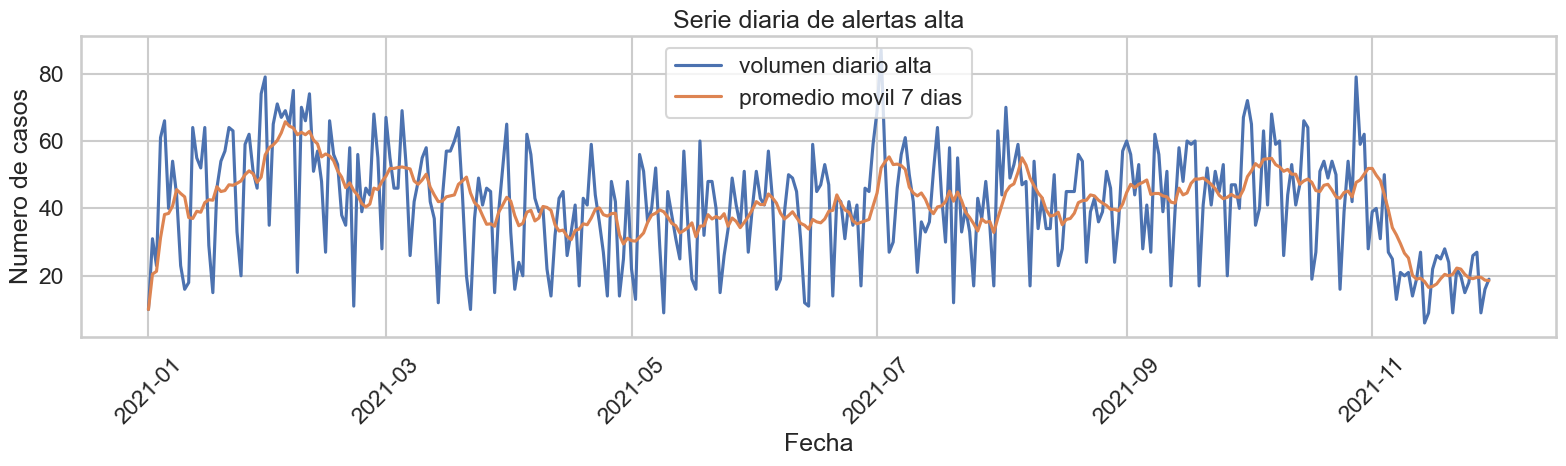

In [44]:
# Grafica la serie temporal de alertas altas para revisar estabilidad y picos operativos.
daily_high_alert_df = detection.build_daily_alert_series(
    alert_table=alert_table,
    alert_level='alta',
)

detection.plot_daily_alert_series(
    series_df=daily_high_alert_df,
    alert_level='alta',
)

In [45]:
# Resume qué tan frecuentes son los casos con 1, 2, 3 o más escenarios activos.
top_scenario_counts_df = detection.build_top_scenario_counts(
    alert_table=alert_table,
    top_n=10,
)

top_scenario_counts_df

,scenario_count,alert_level,n_cases,pct_cases
0,1,pre_alerta,41628,45.020765
1,2,media,36980,39.993944
2,3,alta,12774,13.815106
3,4,alta,1082,1.170185


> `alta` no implica reporte automatico.
>
> `alta` implica revision manual prioritaria para confirmar si el patron observado amerita escalamiento.


### 5.6. Ejemplo graficado de alerta prioritaria

Se selecciona un caso priorizado para recuperar sus transacciones dentro de la ventana y visualizar su patron temporal.


In [46]:
# Prioriza un ejemplo con varios dias de historia observada para la entidad.
min_history_days = 3

entity_history_df = data.groupby(entity_cols, as_index=False).agg(
    n_history_days=('transaction_day', 'nunique'),
    n_history_tx=('_id', 'size'),
)

example_candidates_df = alert_table.merge(
    entity_history_df,
    on=entity_cols,
    how='left',
)

example_df = pd.DataFrame()

for alert_level in ['alta', 'media']:
    level_df = example_candidates_df.loc[
        example_candidates_df['alert_level'] == alert_level,
    ]

    if len(level_df) == 0:
        continue

    history_df = level_df.loc[
        level_df['n_history_days'] >= min_history_days,
    ]

    if len(history_df) > 0:
        example_df = history_df
        break

    if len(example_df) == 0:
        example_df = level_df

example_df = example_df.sort_values(
    ['n_history_days', 'scenario_count', 'tx_count_24h', 'amount_24h'],
    ascending=[False, False, False, False],
)

example_df = example_df.head(1)
example_df = example_df.reset_index(drop=True)

example_df

,user_id,account_number,transaction_type,transaction_day,window_start,window_end,tx_count_24h,amount_24h,avg_amount_24h,std_amount_24h,cv_amount_24h,top_account_number,top_account_tx_count,top_account_amount,n_unique_accounts,top_account_tx_share,top_account_amount_share,top_merchant_id,top_merchant_tx_count,top_merchant_amount,top_merchant_n_subsidiaries,top_merchant_tx_share,top_merchant_amount_share,n_unique_merchants,max_subsidiaries_per_merchant,top_subsidiary,top_subsidiary_tx_count,top_subsidiary_amount,top_subsidiary_tx_share,top_subsidiary_amount_share,n_unique_subsidiaries,tx_count_threshold,amount_threshold,cv_low_threshold,z_day_tx_count,z_day_amount,high_tx_count_24h,high_amount_24h,low_cv_24h,anomalous_tx_count,anomalous_amount,multi_merchant_dispersion,multi_subsidiary_dispersion,multi_subsidiary_same_merchant,scenario_burst_similar,scenario_burst_anomalous,scenario_material_amount,scenario_destination_dispersion,scenario_count,alert_level,is_alert,n_history_days,n_history_tx
0,e4c2d951a3663be6baf10ec6c9b26263,abb90fe99e08a3eabbe8a85a24bca7e8,CREDITO,2021-05-25,2021-05-24 16:42:30,2021-05-25 16:42:30,5.0,852.434849,170.48697,123.683526,0.725472,abb90fe99e08a3eabbe8a85a24bca7e8,5,852.434849,1,1.0,1.0,075d178871d8d48502bf1f54887e52fe,5,852.434849,4,1.0,1.0,1,4,0be5c8077ba85de9782515a621aa39ef,2,535.000951,0.4,0.627615,4,2.0,594.445501,0.0,3.000213,4.476526,1,1,0,1,1,0,1,1,0,1,1,1,3,alta,1,155,287


In [47]:
# Recupera las transacciones originales del caso dentro de la ventana de 24 horas.
example_tx_df = detection.build_alert_example_transactions(
    data=data,
    example_df=example_df,
    entity_cols=entity_cols,
)

example_tx_df

,user_id,account_number,transaction_type,_id,transaction_date,merchant_id,subsidiary,transaction_amount,cumulative_amount
0,e4c2d951a3663be6baf10ec6c9b26263,abb90fe99e08a3eabbe8a85a24bca7e8,CREDITO,b2556d6a7260f7495a8a9f5e4d02663a,2021-05-25 09:50:54,075d178871d8d48502bf1f54887e52fe,d016c01af871514aa5f1f52b2186fc3a,202.111470,202.111470
1,e4c2d951a3663be6baf10ec6c9b26263,abb90fe99e08a3eabbe8a85a24bca7e8,CREDITO,f2b2bb0b70cc2b1812c273c8e50cdb26,2021-05-25 14:59:55,075d178871d8d48502bf1f54887e52fe,0be5c8077ba85de9782515a621aa39ef,356.667301,558.778771
2,e4c2d951a3663be6baf10ec6c9b26263,abb90fe99e08a3eabbe8a85a24bca7e8,CREDITO,6c831dc69ca639dbe90998c32d3234fc,2021-05-25 15:00:57,075d178871d8d48502bf1f54887e52fe,0be5c8077ba85de9782515a621aa39ef,178.333650,737.112422
3,e4c2d951a3663be6baf10ec6c9b26263,abb90fe99e08a3eabbe8a85a24bca7e8,CREDITO,1f7f34d1e435ddf1493ed3101e861844,2021-05-25 15:27:21,075d178871d8d48502bf1f54887e52fe,c62ed6d8c15af861ea74f0d745ce730f,55.877877,792.990299
4,e4c2d951a3663be6baf10ec6c9b26263,abb90fe99e08a3eabbe8a85a24bca7e8,CREDITO,4da103234ecd52d2f70beeefc73174b6,2021-05-25 16:42:30,075d178871d8d48502bf1f54887e52fe,3793690f0554e7df0b45d886a89b9ce2,59.444550,852.434849


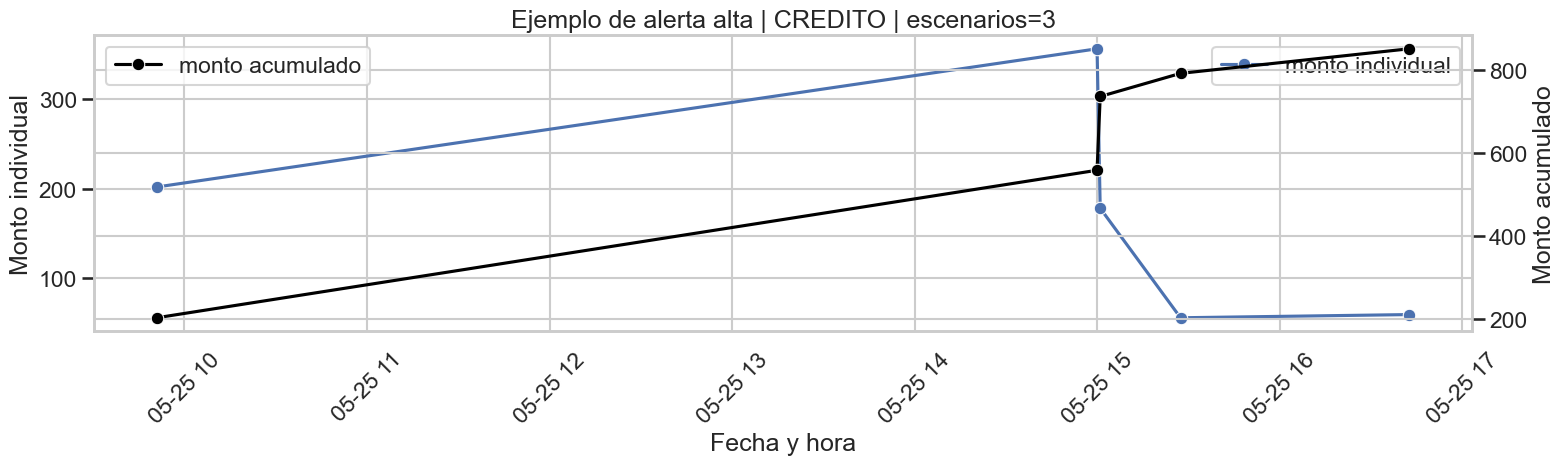

In [48]:
# Grafica el monto individual y el monto acumulado del caso seleccionado.
detection.plot_alert_example(
    example_tx_df=example_tx_df,
    example_df=example_df,
)